In [24]:
#inspecting discovered paramters
# Resources discovered from the log
print("params.resources:", params.resources)

# Working calendar per resource (weekday -> hour -> bool)
print("params.calendars['VC']:", params.calendars["HO2"])

# Per-resource maximum concurrency (1 = no multitasking, >1 = multitasking)
print("params.max_concurrency:", params.max_concurrency)

# Which resources can perform each activity
print("params.act_to_resources:", params.act_to_resources)

# Whether rules mode (Decision Trees) is active
print("params.rules_mode:", params.rules_mode)

# Arrival time model (DecisionRules in rules mode, distribution tuple in no-rules mode)
print("params.arrival_time_distribution:", params.arrival_time_distribution)

# Execution time model per activity (DecisionRules or distribution tuple)
print("params.execution_time_distributions:", params.execution_time_distributions)

# Waiting time model per resource (DecisionRules or distribution tuple)
print("params.waiting_time_distributions:", params.waiting_time_distributions)

# Resource selection: flat dict {resource: DecisionRules|float}. One binary
# classifier per resource, trained on the events where the resource was
# eligible (activity's candidate pool). At simulation time, the engine first
# filters resources via `act_to_resources[activity]`, scores each enabled
# resource with its own tree, and samples proportionally.
print("params.resource_weights:", params.resource_weights)

# Control flow model per transition (DecisionRules in rules mode, float frequency in no-rules)
print("params.transition_weights:", params.transition_weights)

# Case-level data attribute distribution (None if no attributes in log)
print("params.distribution_data_attributes:", params.distribution_data_attributes)
# {'mode': 'empirical', 'data': {(val1, val2): frequency, ...}}
# or {'mode': 'distribution', 'data': {attr: {'type': 'categorical'|'continuous', ...}}}

params.resources: ['Res.GateIn', 'Res.GateOut', 'LL', 'T13', 'T14', 'T16', 'T24', 'T17', 'T15', 'T21', 'T12', 'T22', 'T11', 'T20', 'T23', 'T18', 'T10', 'T27', 'T06', 'T09', 'T08', 'T07', 'T26', 'T19', 'T25', 'HO2']
params.calendars['VC']: {0: {0: False, 1: False, 2: False, 3: False, 4: False, 5: False, 6: True, 7: False, 8: True, 9: True, 10: True, 11: False, 12: True, 13: True, 14: True, 15: True, 16: True, 17: True, 18: True, 19: True, 20: True, 21: True, 22: True, 23: True}, 1: {0: False, 1: True, 2: True, 3: True, 4: False, 5: True, 6: False, 7: True, 8: True, 9: False, 10: True, 11: True, 12: True, 13: True, 14: True, 15: True, 16: True, 17: True, 18: True, 19: True, 20: True, 21: True, 22: True, 23: False}, 2: {0: False, 1: False, 2: False, 3: True, 4: False, 5: True, 6: True, 7: True, 8: False, 9: True, 10: True, 11: True, 12: True, 13: True, 14: True, 15: True, 16: True, 17: True, 18: True, 19: True, 20: True, 21: False, 22: False, 23: True}, 3: {0: False, 1: False, 2: False, 3

In [25]:
for act, model in params.execution_time_distributions.items():
    print(act, len(model.rules))

HO2_mixed 1
HO2_delivery 1
LL_mixed 1
HO2_receive 1
LL_delivery 1
LL_receive 1
Gate In 1
Gate Out 1
RMG_mixed 1
RMG_delivery 1
RMG_receive 1


In [28]:
print("TRANSITIONS")
print("=" * 50)

for name, obj in params.transition_weights.items():

    if hasattr(obj, "rules"):
        print(
            name,
            "->",
            len(obj.rules)
        )

TRANSITIONS
skip_8 -> 7
skip_3 -> 3
tauSplit_9 -> 7
skip_11 -> 3
skip_12 -> 3
d6b2d559-3ebc-4a33-a206-2ca38469d497 -> 3
7f339cf2-808a-4cff-9eb1-e5388117da46 -> 3
skip_13 -> 5
tauSplit_14 -> 3
skip_22 -> 11
tauSplit_23 -> 7
skip_16 -> 3
skip_25 -> 5
skip_26 -> 3
c298b648-a5a4-426d-941c-f0a2dd821883 -> 7
9eb3597e-a143-49b2-87cf-68a0d75d039c -> 5
skip_27 -> 7
tauSplit_28 -> 7
8299a989-86f8-4123-9f6a-6a4ff76ab56f -> 13
skip_30 -> 3
b0af8e19-c305-4de7-9135-ae29a2c0fcb5 -> 3
899c40da-2778-4a03-83f6-0761155d416e -> 3


In [29]:
print("RESOURCE WEIGHTS")
print("=" * 50)

for name, obj in params.resource_weights.items():

    if hasattr(obj, "rules"):
        print(
            name,
            "->",
            len(obj.rules)
        )

RESOURCE WEIGHTS
T13 -> 3
T14 -> 3
T16 -> 3
T24 -> 3
T17 -> 3
T15 -> 3
T21 -> 3
T12 -> 3
T22 -> 3
T11 -> 3
T20 -> 3
T23 -> 3
T18 -> 3
T10 -> 3
T27 -> 3
T06 -> 3
T09 -> 3
T08 -> 3
T07 -> 3
T26 -> 3
T19 -> 3
T25 -> 3


In [30]:
print(
    params.resource_weights["T24"].rules
)

{0: {'feature': 'target_block = T24', 'threshold': 0.5, 'children': {True: 1, False: 2}}, 1: {'value': 0.0}, 2: {'value': 1.0}}


In [31]:
print(
params.transition_weights["skip_22"].rules
)

{0: {'feature': 'visit_complexity', 'threshold': 10.5, 'children': {True: 1, False: 6}}, 1: {'feature': 'LL_delivery', 'threshold': 0.5, 'children': {True: 2, False: 5}}, 2: {'feature': 'visit_complexity', 'threshold': 8.5, 'children': {True: 3, False: 4}}, 3: {'value': 0.501}, 4: {'value': 0.036}, 5: {'value': 1.0}, 6: {'feature': 'n_stops', 'threshold': 1.5, 'children': {True: 7, False: 8}}, 7: {'value': 0.0}, 8: {'feature': 'visit_complexity', 'threshold': 12.5, 'children': {True: 9, False: 10}}, 9: {'value': 0.472}, 10: {'value': 0.041}}


In [32]:
for res in [
    "T24",
    "T23",
    "T22",
    "T21"
]:

    print("=" * 60)
    print(res)
    print(
        params.resource_weights[res].rules
    )

T24
{0: {'feature': 'target_block = T24', 'threshold': 0.5, 'children': {True: 1, False: 2}}, 1: {'value': 0.0}, 2: {'value': 1.0}}
T23
{0: {'feature': 'target_block = T23', 'threshold': 0.5, 'children': {True: 1, False: 2}}, 1: {'value': 0.0}, 2: {'value': 1.0}}
T22
{0: {'feature': 'target_block = T22', 'threshold': 0.5, 'children': {True: 1, False: 2}}, 1: {'value': 0.0}, 2: {'value': 1.0}}
T21
{0: {'feature': 'target_block = T21', 'threshold': 0.5, 'children': {True: 1, False: 2}}, 1: {'value': 0.0}, 2: {'value': 1.0}}


In [33]:
for name, obj in params.transition_weights.items():

    if hasattr(obj, "rules"):

        print("=" * 60)
        print(name)

        root = obj.rules[0]

        print(root)

skip_8
{'feature': 'n_receives', 'threshold': 0.5, 'children': {True: 1, False: 2}}
skip_3
{'feature': 'n_receives', 'threshold': 0.5, 'children': {True: 1, False: 2}}
tauSplit_9
{'feature': 'n_receives', 'threshold': 0.5, 'children': {True: 1, False: 2}}
skip_11
{'feature': 'process_flow_type = mixed', 'threshold': 0.5, 'children': {True: 1, False: 2}}
skip_12
{'feature': 'n_stops', 'threshold': 1.5, 'children': {True: 1, False: 2}}
d6b2d559-3ebc-4a33-a206-2ca38469d497
{'feature': 'process_flow_type = mixed', 'threshold': 0.5, 'children': {True: 1, False: 2}}
7f339cf2-808a-4cff-9eb1-e5388117da46
{'feature': 'n_stops', 'threshold': 1.5, 'children': {True: 1, False: 2}}
skip_13
{'feature': 'RMG_delivery', 'threshold': 0.5, 'children': {True: 1, False: 2}}
tauSplit_14
{'feature': 'RMG_delivery', 'threshold': 0.5, 'children': {True: 1, False: 2}}
skip_22
{'feature': 'visit_complexity', 'threshold': 10.5, 'children': {True: 1, False: 6}}
tauSplit_23
{'feature': 'visit_complexity', 'thresho

In [26]:
for k, v in params.transition_weights.items():

    if hasattr(v, "rules"):

        print(k)
        print(len(v.rules))
        print()

skip_8
7

skip_3
3

tauSplit_9
7

skip_11
3

skip_12
3

d6b2d559-3ebc-4a33-a206-2ca38469d497
3

7f339cf2-808a-4cff-9eb1-e5388117da46
3

skip_13
5

tauSplit_14
3

skip_22
11

tauSplit_23
7

skip_16
3

skip_25
5

skip_26
3

c298b648-a5a4-426d-941c-f0a2dd821883
7

9eb3597e-a143-49b2-87cf-68a0d75d039c
5

skip_27
7

tauSplit_28
7

8299a989-86f8-4123-9f6a-6a4ff76ab56f
13

skip_30
3

b0af8e19-c305-4de7-9135-ae29a2c0fcb5
3

899c40da-2778-4a03-83f6-0761155d416e
3



In [16]:
import pandas as pd
import prosit

print(pd.__version__)
print(prosit.__version__)

1.5.3
1.0.3


In [1]:
import warnings
warnings.filterwarnings("ignore")

import pm4py
import pm4py.objects.log.importer.xes.importer as xes_importer
from prosit import SimulatorParameters, SimulatorEngine
from datetime import datetime

# 1. Load event log
log = xes_importer.apply("../../data/processed/CTB/xes_files/s5_sample_20.000_eventlog_one_block_binned_features.xes")
print("loaded .xes")



  Welcome to PM4Py — Community Version
  Open-Source License (AGPL v3)

  📚 Docs & Examples:
     https://processintelligence.solutions/pm4py

  ⚖️  License: AGPL v3 — Commercial use requires open-sourcing your application.
     Business use without open-sourcing? A commercial license is available:
     https://processintelligence.solutions/pm4py#licensing


parsing log, completed traces :: 100%|██████████| 20000/20000 [00:10<00:00, 1926.86it/s]

loaded .xes


In [2]:
# Full Log
# Split: use 80% for discovery, compare simulation against remaining 20%
n_cases = len(log)
#train_log = log[:int(n_cases * 0.8)]
#test_log  = log[int(n_cases * 0.8):]
from pm4py.objects.log.obj import EventLog

n_cases = len(log)

train_log = EventLog(
    list(log[:int(n_cases * 0.8)])
)

test_log = EventLog(
    list(log[int(n_cases * 0.8):])
)
print(f"Split into training set ({len(train_log)} cases) and test set ({len(test_log)} cases)")

# Discover from training set
net, im, fm = pm4py.discover_petri_net_inductive(train_log)
params = SimulatorParameters(net, im, fm)


Split into training set (16000 cases) and test set (4000 cases)


In [3]:
df_train = pm4py.convert_to_dataframe(
    train_log
)

print(df_train.columns.tolist())

['concept:name', 'org:resource', 'enabled:timestamp', 'start:timestamp', 'time:timestamp', 'process_flow_type', 'n_containers', 'n_stops', 'n_deliveries', 'n_receives', 'has_hazardous', 'has_reefer', 'full_ratio', 'visit_complexity', 'gate_demand', 'rmg_demand', 'vc_demand', 'mt_demand', 'gate_utilization', 'rmg_utilization', 'vc_utilization', 'mt_utilization', 'target_block', 'target_utilization', 'target_demand', 'target_utilization_bin', 'target_demand_bin', '@@index', '@@case_index', 'case:concept:name']


In [4]:
print(
    "Activities:",
    df_train["concept:name"].nunique()
)

print(
    sorted(
        df_train["concept:name"]
        .unique()
    )[:100]
)
print(
    "Resources:",
    df_train["org:resource"].nunique()
)

print(
    sorted(
        df_train["org:resource"]
        .dropna()
        .unique()
    )
)
print(
    df_train.dtypes
)

Activities: 11
['Gate In', 'Gate Out', 'HO2_delivery', 'HO2_mixed', 'HO2_receive', 'LL_delivery', 'LL_mixed', 'LL_receive', 'RMG_delivery', 'RMG_mixed', 'RMG_receive']
Resources: 26
['HO2', 'LL', 'Res.GateIn', 'Res.GateOut', 'T06', 'T07', 'T08', 'T09', 'T10', 'T11', 'T12', 'T13', 'T14', 'T15', 'T16', 'T17', 'T18', 'T19', 'T20', 'T21', 'T22', 'T23', 'T24', 'T25', 'T26', 'T27']
concept:name                           object
org:resource                           object
enabled:timestamp         datetime64[ns, UTC]
start:timestamp           datetime64[ns, UTC]
time:timestamp            datetime64[ns, UTC]
process_flow_type                      object
n_containers                            int64
n_stops                                 int64
n_deliveries                            int64
n_receives                              int64
has_hazardous                           int64
has_reefer                              int64
full_ratio                            float64
visit_complexity       

In [5]:
print(
    df_train[
        [
            "concept:name",
            "org:resource"
        ]
    ]
    .drop_duplicates()
    .shape
)
df_train[
    [
        "concept:name",
        "org:resource"
    ]
].drop_duplicates()

(74, 2)


,concept:name,org:resource
0,Gate In,Res.GateIn
1,LL_delivery,LL
2,RMG_mixed,T24
3,Gate Out,Res.GateOut
5,RMG_delivery,T11
...,...,...
3872,HO2_receive,HO2
6568,RMG_delivery,T16
6694,RMG_mixed,T16
7088,RMG_receive,T16


In [6]:
import pm4py

df_train = pm4py.convert_to_dataframe(
    train_log
)

from collections import Counter

c = Counter(df_train.columns)

duplicates = {
    k:v
    for k,v in c.items()
    if v > 1
}

print(duplicates)
cols = list(df_train.columns)

print(
    len(cols),
    len(set(cols))
)

{}
30 30


In [7]:
# Uses use_workload_features=True
params.discover_from_eventlog(
    train_log,
    max_depth_tree=5,
    min_samples_leaf_cv=[5,10,20],
    random_state=42,
    verbose=True,
    use_workload_features=True
)
print(f"Discovered parameters: {params}")
# Simulate the same number of cases as the test set
engine = SimulatorEngine(params)


Resources discovery...
Data attributes discovery...
PATCHED 1.0 script is running
Feature discovery...


100%|██████████| 16000/16000 [00:16<00:00, 963.84it/s] 


Transition Probabilities discovery...


transition models: 100%|██████████| 43/43 [00:30<00:00,  1.40it/s]


Resource Weights discovery...


...

Calendars discovery...
Execution Time discovery...


exec-time models: 100%|██████████| 11/11 [00:03<00:00,  3.37it/s]


Waiting Time discovery...


waiting-time models: 100%|██████████| 26/26 [00:05<00:00,  4.97it/s]


Arrival Time discovery...
Discovered parameters: <prosit.simulator.SimulatorParameters object at 0x0000029FC4AD1210>


In [8]:
import time

print(time.strftime("%H:%M:%S"))


11:21:40


In [10]:
for act, model in params.execution_time_distributions.items():
    print(act)

    if hasattr(model, "rules"):
        print(model.rules)

LL_receive
{0: {'value': 10.71875, 'dist': (<scipy.stats._continuous_distns.expon_gen object at 0x0000029FB9D53AC0>, (4.0, 6.71875), 4.0, 58.0), 'sampled': [5.027438803686579, 6.08680332377869, 6.579876811876309, 4.574716250879226, 4.440872544193507, 11.630724310046995, 11.398165170387522, 10.10991504406121, 12.178184754053998, 5.691769354653993, 21.38868108055313, 6.92491907385001, 4.843222304186058, 5.200644540747398, 16.042075175578653, 9.309571569950373, 8.331078886859995, 8.454905328639086, 10.116076407806998, 7.274683384840088, 13.140148891044772, 12.593770179406658, 6.9779968532284675, 7.943326147958574, 4.968670648469726, 9.394024276203357, 24.591176592415398, 12.114399252463636, 28.17934174423515, 12.704992177560213, 4.357742539227092, 5.349038566854934, 11.353516655540556, 12.403097452882124, 37.35954750155537, 4.994505748985001, 32.55394000409737, 4.4648807525225305, 4.2744354893966, 8.087321937260807, 5.7057548596763965, 10.316158555846089, 8.86273661430549, 5.6145484360154

In [12]:
print(

params.execution_time_distributions.keys()

)
for act, model in (
    params.execution_time_distributions.items()
):

    print(
        act,
        len(model.rules)
    )

dict_keys(['LL_receive', 'HO2_mixed', 'HO2_receive', 'LL_delivery', 'LL_mixed', 'HO2_delivery', 'Gate In', 'Gate Out', 'RMG_mixed', 'RMG_delivery', 'RMG_receive'])
LL_receive 1
HO2_mixed 1
HO2_receive 1
LL_delivery 1
LL_mixed 1
HO2_delivery 1
Gate In 1
Gate Out 1
RMG_mixed 1
RMG_delivery 1
RMG_receive 1


In [13]:
rmg_df = df_train[

df_train["concept:name"] == "RMG_mixed"

]

In [14]:
for f in [
    "target_utilization",
    "target_demand",
    "visit_complexity"
]:
    print(
        f,
        rmg_df[f].nunique()
    )


target_utilization 1717
target_demand 630
visit_complexity 18


In [16]:
import pandas as pd
df_train["service_time"] = (
    pd.to_datetime(df_train["time:timestamp"])
    -
    pd.to_datetime(df_train["start:timestamp"])
).dt.total_seconds() / 60

In [17]:
df_train["service_time"] = (
    pd.to_datetime(df_train["time:timestamp"])
    -
    pd.to_datetime(df_train["start:timestamp"])
).dt.total_seconds()/60

rmg_df = df_train[
    df_train["concept:name"]=="RMG_mixed"
]


In [18]:
for v in [
    "target_utilization",
    "target_demand",
    #"gatein_hour",
    "n_containers"
]:
    print(v)
    print(
        rmg_df[[v,"service_time"]]
        .corr()
    )

target_utilization
                    target_utilization  service_time
target_utilization            1.000000      0.073043
service_time                  0.073043      1.000000
target_demand
               target_demand  service_time
target_demand        1.00000       0.04184
service_time         0.04184       1.00000
n_containers
              n_containers  service_time
n_containers      1.000000      0.273285
service_time      0.273285      1.000000


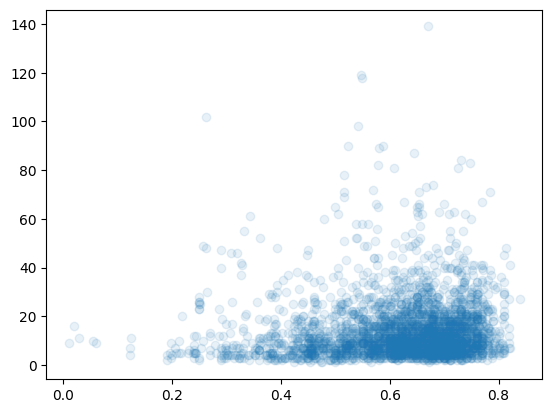

In [19]:
import matplotlib.pyplot as plt

plt.scatter(
    rmg_df["target_utilization"],
    rmg_df["service_time"],
    alpha=0.1
)

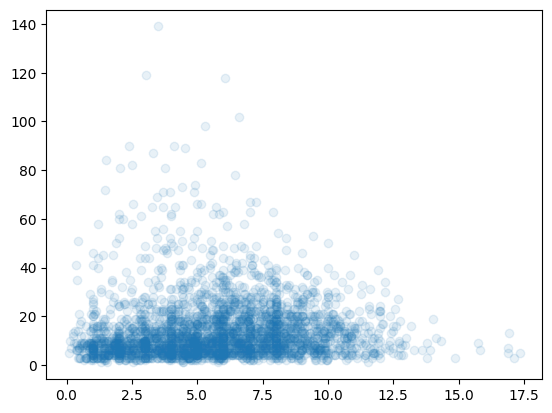

In [20]:
plt.scatter(
    rmg_df["target_demand"],
    rmg_df["service_time"],
    alpha=0.1
)

In [21]:
rmg_df = df_train[
    df_train["concept:name"] == "RMG_mixed"
]

rmg_df[
    [
        "target_utilization",
        "service_time"
    ]
].corr()

,target_utilization,service_time
target_utilization,1.000000,0.073043
service_time,0.073043,1.000000


In [22]:
model = params.execution_time_distributions["RMG_mixed"]

print(type(model))

print(vars(model))

<class 'prosit.utils.rule_utils.DecisionRules'>
{'rules': {0: {'value': 14.140859481582538, 'dist': (<scipy.stats._continuous_distns.lognorm_gen object at 0x000002A002852410>, (0.7813796826791772, 0.27507003340115604, 10.242382306218651), 1.0, 139.0), 'sampled': [9.193064275631585, 31.974031677606824, 4.182515370772573, 4.78585454633066, 14.795331384901433, 47.75386351772488, 4.934151898053605, 5.883944134947118, 5.948892953182273, 6.840155254920972, 7.015215608781619, 26.706426374453535, 5.096894667913145, 47.74880334251409, 8.089951251157848, 8.74214363273331, 14.093547058815927, 24.417023137343055, 28.721566476217717, 2.3567411684119275, 4.680086525102791, 12.623940295632117, 15.777278234437016, 26.76116797642324, 1.5008547920031847, 10.128458980313745, 5.165961344081696, 21.964565888636148, 19.389237714396035, 4.250488493827918, 33.84938649372221, 33.30659713454635, 17.84840494680316, 10.849384934627244, 25.330838987120714, 9.111578821971229, 7.500826876235115, 12.530156163144508, 

In [23]:
dir(model)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'apply',
 'apply_distribution',
 'from_decision_tree',
 'from_river_decision_tree',
 'graph',
 'rules',
 'write_dot']

In [24]:
for act, model in params.execution_time_distributions.items():
    print(act)

    if hasattr(model, "rules"):
        print(model.rules)

LL_receive
{0: {'value': 10.71875, 'dist': (<scipy.stats._continuous_distns.expon_gen object at 0x0000029FB9D53AC0>, (4.0, 6.71875), 4.0, 58.0), 'sampled': [5.027438803686579, 6.08680332377869, 6.579876811876309, 4.574716250879226, 4.440872544193507, 11.630724310046995, 11.398165170387522, 10.10991504406121, 12.178184754053998, 5.691769354653993, 21.38868108055313, 6.92491907385001, 4.843222304186058, 5.200644540747398, 16.042075175578653, 9.309571569950373, 8.331078886859995, 8.454905328639086, 10.116076407806998, 7.274683384840088, 13.140148891044772, 12.593770179406658, 6.9779968532284675, 7.943326147958574, 4.968670648469726, 9.394024276203357, 24.591176592415398, 12.114399252463636, 28.17934174423515, 12.704992177560213, 4.357742539227092, 5.349038566854934, 11.353516655540556, 12.403097452882124, 37.35954750155537, 4.994505748985001, 32.55394000409737, 4.4648807525225305, 4.2744354893966, 8.087321937260807, 5.7057548596763965, 10.316158555846089, 8.86273661430549, 5.6145484360154

In [25]:
params.execution_time_distributions["RMG_mixed"]

In [28]:
sim_log = engine.apply(
    n_traces=len(train_log),
    #t_start=datetime(2024, 1, 1, 8, 0, 0)
)



Simulating Cases: 100%|██████████| 16000/16000 [00:20<00:00, 794.73it/s]


OSError: Cannot save file into a non-existent directory: '..\..\..\data\processed\CTB\prosit_simulations'

In [29]:
sim_log.to_csv("../../data/processed/CTB/prosit_simulations/sim_log_s5_baseline_sample_20.000_v3_binning.csv")
print(f"Simulated {len(sim_log)} events across {sim_log['case:concept:name'].nunique()} cases")

Simulated 48290 events across 16000 cases


In [30]:
#SAVE PARAMS TO JSON!!
params.to_json("s5_baseline_with_binning_params.json")

""" From 
# --- Discover once ---
params = SimulatorParameters(net, im, fm)
params.discover_from_eventlog(log, max_depth_tree=3)
params.to_json("my_params.json")

# --- Load and simulate later ---
params2 = SimulatorParameters(net, im, fm)
params2.from_json("my_params.json")

engine = SimulatorEngine(params2)
sim_log = engine.apply(n_traces=1000) """

' From \n# --- Discover once ---\nparams = SimulatorParameters(net, im, fm)\nparams.discover_from_eventlog(log, max_depth_tree=3)\nparams.to_json("my_params.json")\n\n# --- Load and simulate later ---\nparams2 = SimulatorParameters(net, im, fm)\nparams2.from_json("my_params.json")\n\nengine = SimulatorEngine(params2)\nsim_log = engine.apply(n_traces=1000) '

In [ ]:
print(params.max_concurrency)

NameError: name 'params' is not defined

In [33]:
#SAVE PARAMS TO JSON!!
params.to_json("../../data/processed/CTB/prosit_params/s5_baseline_with_binning_params.json")

In [36]:
import pickle

with open(
    "../../data/processed/CTB/prosit_params/s5_baselinewith_binning_params.json",
    "wb"
) as f:

    pickle.dump(
        params,
        f
    )

=============== Analyse des Sim Logs ================

In [37]:
for k, v in params.distribution_data_attributes.items():
    print("\n", "="*50)
    print(k)
    print(v)



mode
distribution

data
{'target_demand': {'type': 'continuous', 'dist': 'norm', 'params': [5.97800625, 2.9952952254261915], 'min': 0.0, 'max': 17.87, 'mean': 5.97800625}, 'vc_demand': {'type': 'continuous', 'dist': 'lognorm', 'params': [0.25149830673253004, -25.38993327680334, 43.632067558689826], 'min': 0.0, 'max': 57.85, 'mean': 19.631620625}, 'mt_demand': {'type': 'continuous', 'dist': 'norm', 'params': [18.5303775, 10.368819772881277], 'min': 0.0, 'max': 52.85, 'mean': 18.5303775}, 'mt_utilization': {'type': 'continuous', 'dist': 'norm', 'params': [0.82832981875, 0.05272753341677523], 'min': 0.69, 'max': 0.93, 'mean': 0.82832981875}, 'rmg_demand': {'type': 'continuous', 'dist': 'norm', 'params': [100.468025, 38.130812099591786], 'min': 1.93, 'max': 206.0, 'mean': 100.468025}, 'rmg_utilization': {'type': 'continuous', 'dist': 'norm', 'params': [0.5606755625000001, 0.04355950163636624], 'min': 0.4358, 'max': 0.64, 'mean': 0.5606755625000001}, 'target_utilization': {'type': 'continu

In [38]:
interesting = [
    "n_containers",
    "n_stops",
    "n_deliveries",
    "n_receives",
    "visit_complexity"
]

for feat in interesting:

    print("\n" + "=" * 50)
    print(feat)

    print(
        params.distribution_data_attributes["data"][feat]
    )


n_containers
{'type': 'continuous', 'dist': 'gamma', 'params': [0.21214326775628506, 0.9999999999999999, 0.30385458954805933], 'min': 1.0, 'max': 4.0, 'mean': 1.18025}

n_stops
{'type': 'continuous', 'dist': 'lognorm', 'params': [9.824473554073577, 0.9999999999999998, 4.0884285372194826e-15], 'min': 1.0, 'max': 3.0, 'mean': 1.0811875}

n_deliveries
{'type': 'continuous', 'dist': 'norm', 'params': [0.547, 0.5836660003803545], 'min': 0.0, 'max': 4.0, 'mean': 0.547}

n_receives
{'type': 'continuous', 'dist': 'norm', 'params': [0.78275, 0.49817410360234504], 'min': 0.0, 'max': 4.0, 'mean': 0.78275}

visit_complexity
{'type': 'continuous', 'dist': 'lognorm', 'params': [0.6586663619589701, 1.546217233861411, 3.846358270626542], 'min': 2.0, 'max': 26.0, 'mean': 6.349125}


In [39]:
print(
    params.distribution_data_attributes["data"]["n_containers"]
)

{'type': 'continuous', 'dist': 'gamma', 'params': [0.21214326775628506, 0.9999999999999999, 0.30385458954805933], 'min': 1.0, 'max': 4.0, 'mean': 1.18025}


In [40]:
print(
    "Activities:",
    len(
        params.net_transition_labels
    )
)

print(
    "Resources:",
    len(
        params.resources
    )
)

print(
    "Data Attributes:",
    len(
        params.label_data_attributes
    )
)

Activities: 11
Resources: 26
Data Attributes: 24
